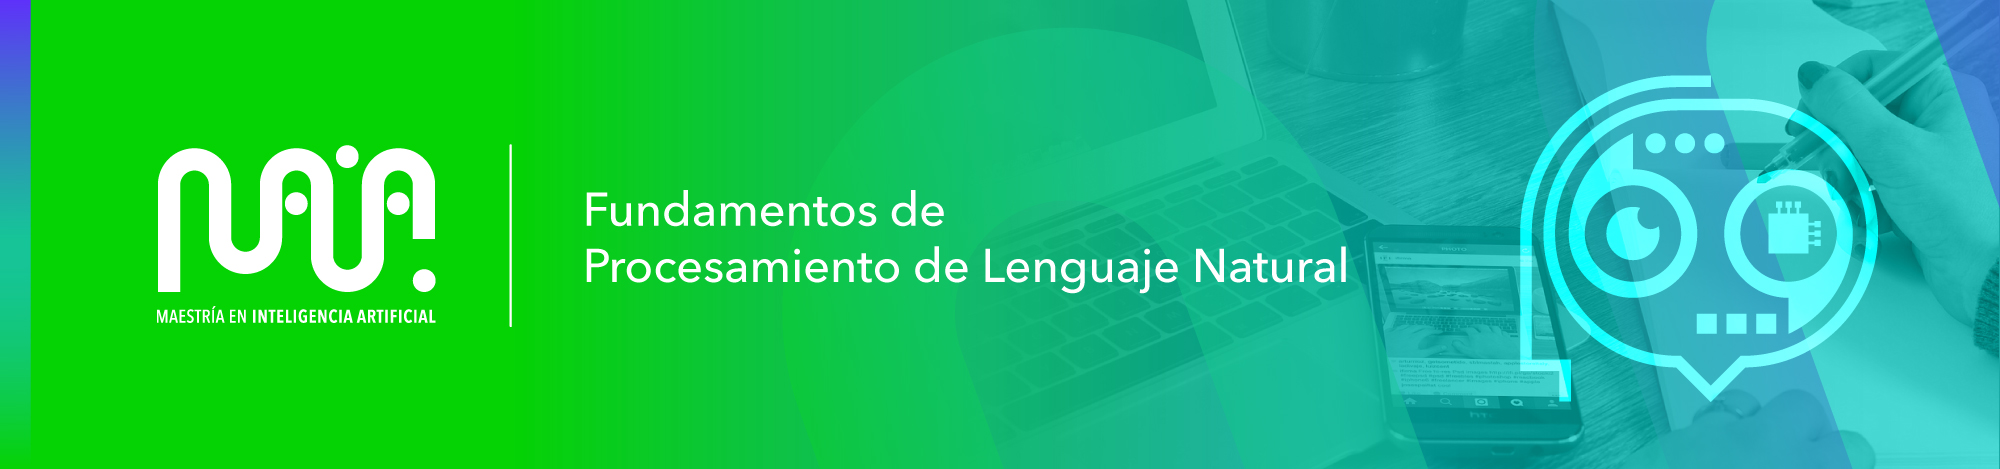

# Introducción

## Descripción
Mediante este notebook de Python se busca evaluar el conocimiento del estudiante para implementar y evaluar sistemas de recuperación de información simples.

Al final del desarrollo de este notebook se espera que el estudiante este en capacidad de:
1. Aplicar técnicas de procesamiento de texto a problemas reales.
2. Hacer uso de **gensim** para construir sistemas de recuperación de información.
3. Implementar métricas de evaluación de sistemas de recuperación.
4. Medir el desempeño de los sistemas de recuperación de información.

## Metodología
Este notebook consiste en la creación de un sistema de recuperación de información para los documentos recolectados por el "Center for Inventions and Scientific Information" (CISI). El dataset contiene 1.460 documentos y 112 consultas que usaremos para crear el sistema de recuperación y para evaluar el desemepeño del mismo.

Estuctura del taller:
* [1. Implementar métricas de evaluación](#1-implementar-métricas-de-evaluación)
    * [1.1. Ejercicio 1: Implementar el indicador de precisión](#11-ejercicio-1-implementar-la-métrica-de-precisión)
    * [1.2. Ejercicio 2: Implementar el recall](#12-ejercicio-2-implementar-la-métrica-de-recall)
    * [1.3. Ejercicio 3: Implementar la precisión promedio](#13-ejercicio-3-implementar-la-precisión-promedio)
    * [1.4. Ejercicio 4: Implementar el MAP](#14-ejercicio-4-implementa-la-métrica-map)
* [2. Explorar el dataset CISI](#2-explorar-el-dataset-cisi-de-recuperación-de-información)
* [3. Construir el sistema de recuperación de información](#3-construir-el-sistema-de-recuperación-de-información)
    * [3.1. Ejercicio 5: Implementación de sistema de IR con **gensim**](#31-ejercicio-5-implementación-del-sistema-de-recuperación-de-información-con-gensim)
    * [3.2. Entrenar el sistema de recuperación en el corpus real](#32-crear-el-sistema-de-recuperación-con-el-corpus-real)
* [4. Evaluación del sistema de recuperación de información](#4-evaluación-del-sistema-de-recuperación-de-información-construido)

## Consideraciones
* Solo debe completar las funciones que se le indique de manera explícita.
* Este notebook se autocalificará mediante unos tests ocultos que probarán las funcionalidades implementadas.

Importación de los módulos a usar en el taller

In [1]:
import re
import numpy as np
import nltk
import pprint
from gensim.utils import simple_preprocess
from gensim import corpora
from gensim import models
from gensim import similarities

# Importe otros módulos que necesite aquí. De no necesitarlo eliminar el "raise"
# para que la celda no genere error
# your code here
#raise NotImplementedError

## 1. Implementar métricas de evaluación

Cuando tenemos los documentos relevantes para un grupo de consultas, podemos utilizar estas etiquetas para medir el desempeño de nuestro sistema de recuperación. En este taller, usted debe implementar las principales métricas de evaluación para medir el desempeño del sistema de recuperación que vamos a constuir.

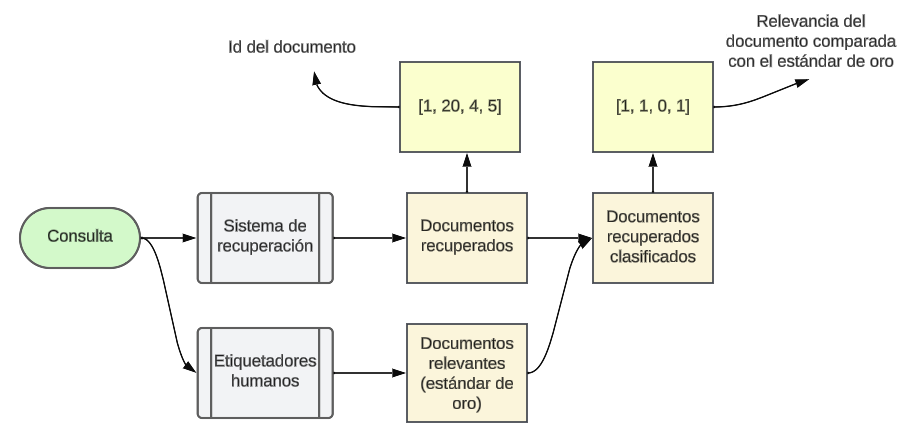

## 1.1 Ejercicio 1: Implementar la métrica de precisión

En este ejercicio usted debe implementar la métrica de precisión, esta métrica mide la relevancia de los documentos recuperados por el sistema considerando *k* documentos recuperados. En donde 1 representa que los *k* documentos son relevantes para la consulta, y 0 representa que ninguno lo es.

In [2]:
def precision_at_k(classified_docs: list, k: int) -> float:
    """
    Esta función calcula la precisión hasta el k-ésimo documento. La precisión es
    la cantidad de documentos relevantes recuperados dividido por el número total
    de documentos recuperados.

    Args:
    - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.
    - k: Número de documentos a tomar en cuenta en la precisión.

    Returns:
    - Precisión para los primeros k documentos recuperados.

    Ejemplo:
    precision_at_k([1, 1, 0, 0, 1], 4) = 0.5
    """
    
    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    recorte = classified_docs[:k]
    doc_rele_re = sum(recorte)
    precision = doc_rele_re / k
    return precision
    #raise NotImplementedError

## 1.2 Ejercicio 2: Implementar la métrica de recall

Implemente una función que mida el *recall* para los primeros *k* documentos recuperados por el sistema. El *recall** evalúa que cantidad de documentos relevantes fueron recuperados frente al total de documentos relecantes. 

In [3]:
def recall_at_k(classified_docs: list, relevant_docs_number: int, k: int) -> float:
    """
    Esta función calcula el recall hasta el k-ésimo documento. El recall es
    la cantidad de documentos relevantes recuperados dividido por el número total
    de documentos relevantes.

    Args:
    - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.
    - relevant_docs_number: Número total de documentos relevantes para la consulta según el estándar de oro.
    - k: Número de documentos a tomar en cuenta en el recall.

    Returns:
    - Recall para los primeros k documentos recuperados.

    Ejemplo:
    recall_at_k([1 ,1, 0, 0], 10, 4) = 0.2
    """

    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    recorte = classified_docs[:k]
    doc_rele_re = sum(recorte)
    recall = doc_rele_re / relevant_docs_number
    return recall
    #raise NotImplementedError

## 1.3. Ejercicio 3: Implementar la precisión promedio

La precisión promedio como su nombre lo indica, es el promedio de todos los niveles de *k* posibles, desde 1 hasta que se recuperan todos los documentos relecantes para la consulta (*recall* es igual a 1). Para el promedio de la precisión solo se consideran los niveles de *k* para los cuales el documento *k* es relevante.

In [4]:
def average_precision(classified_docs: list) -> float:
    """
    Esta función calcula el promedio de la precisión para todos los k posibles hasta que se recuperen todos los documentos relevantes.
    Esta función asume que los documentos en classified_docs contiene todos los documentos del corpus.

    Args:
    - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.

    Returns:
    - Promedio de la precisión para todos los k posibles hasta que se recuperen todos los documentos relevantes.

    Ejemplo:
    average_precision([1, 0, 1, 1]) = 0.805...
    """

    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    suma_precisiones = 0
    conteo_relevantes = 0
    k=0
    for i in range(len(classified_docs)):
        k = i + 1
        if classified_docs[i] == 1:
            conteo_relevantes += 1
            average_presicion = conteo_relevantes/k
            suma_precisiones = suma_precisiones + average_presicion
    if conteo_relevantes == 0:
        return 0.0
    return suma_precisiones / conteo_relevantes
    #raise NotImplementedError

## 1.4. Ejercicio 4: Implementa la métrica MAP

El *MAP* nos permite medir el desempeño de nuestro sistema de recuperación de información para un grupo de consultas, para lo cual se promedia la precisión promedio obtenida para cada una de las consultas.

In [5]:
def MAP(relevance_query_group: list) -> float:
    """
    Esta función calcula el promedio de average precision para un grupo de consultas.

    Args:
    - relevance_query_group: Lista de listas de documentos recuperados para cada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.

    Returns:
    - Promedio de average precision para un grupo de consultas.

    Ejemplo:
    MAP([[1, 0, 1, 0], [1, 0, 0, 0]]) = 0.916...
    """

    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    cantidad_consultas = 0
    resultado = 0
    for consulta in relevance_query_group:
        resultado = resultado + average_precision(consulta)
    return resultado/len(relevance_query_group)
     
    
    
    #raise NotImplementedError

# 2. Explorar el dataset CISI de recuperación de información

El dataset de CISI fue extraído de Kagggle. Puede explorarlo [aquí](https://www.kaggle.com/datasets/dmaso01dsta/cisi-a-dataset-for-information-retrieval/data).
Este dataset fue públicamente distribuido por la Universidad de Glasgow. Los documentos fueron recolectados por el "Center for Inventions and Scientific Information" (CISI) y consiste en 1.460 documentos y 112 consultas asociadas.

El propósito del dataset es permitir la construcción de modelos de recuperación de información donde para cada consulta se deberían recuperar los documentos relevantes. El dataset consiste en 3 archivos:

* CISI.ALL: Archivo de texto con todos los documentos, en donde cada documento está compuesto por un id, un título, un autor, un abstract, y los documentos relacionados al documento.
* CISI.QRY: Este archivo de texto contiene 112 consultas, cada una se compone de por lo menos de un id y el texto de consulta.
* CISI.REL: Este archivo contiene el estándar de oro, y por lo tanto, relaciona los documentos relevantes para cada consulta.

En primera instancia exploraremos el contenido de cada uno de estos archivos, inicando por CISI.ALL

In [6]:
with open('CISI_dataset/CISI.ALL') as f:
    cisi_raw_docs = f.read()

pattern = r'''(?x)    # Flag para modo verbose
    (?:\.I\s*(\d+)\s*)   # ID del documento
    (?:\.T\s*(.*?)\n\.A)   # Título
    (?:\s*(.*?)\n\.W)   # Autor
    (?:\s*(.*?)\n\.X)   # Abstract
'''

# Se extraen los documentos del archivo CISI.ALL
data = re.findall(pattern, cisi_raw_docs, flags=re.DOTALL)

# Se crea un corpus con los títulos y abstracts de los documentos
class MyCorpus:
    def __iter__(self):
        for d in data:
        # Para cada documento, se concatenan el título y el abstract
            yield d[1] + '\n' + d[3]

    def __len__(self):
        return len(data)

    # Se implementa el método __getitem__ para poder acceder a los documentos por índice
    def __getitem__(self, idx):
        return data[idx][1] + '\n' + data[idx][3]
    
corpus = MyCorpus()

Primero hacemos uso de las expresiones regulares para extraer el contenido relevante del archivo. Luego construimos nuestro corpus como un listado de documentos (texto), en donde cada documento será representado por la concatenación del título y el abstract.

A continuación se muestra el contenido del tercer documento del corpus:

In [7]:
print(corpus[2])

Two Kinds of Power
An Essay on Bibliographic Control
The relationships between the organization and control of writings
and the organization and control of knowledge and information will
inevitably enter our story, for writings contain, along with much else, a
great deal of mankind's stock of knowledge and information.  Bibliographical
control is a form of power, and if knowledge itself is a form of power,
as the familiar slogan claims, bibliographical control is in a certain sense
power over power, power to obtain the knowledge recorded in written
form.  As writings are not simply, and not in any simple way, storehouses of
knowledge, we cannot satisfactorily discuss bibliographical control as
simply control over the knowledge and information contained in writings.


In [8]:
print(f"Número de documentos en el corpus: {len(corpus)}")

Número de documentos en el corpus: 1460


Ahora, exploraremos el archivo CISI.QRY que contiene toda la información relacionada a las consultas.

In [9]:
with open('CISI_dataset/CISI.QRY') as f:
    queries_raw = f.read()

pattern = r'''(?x)    # Flag para modo verbose
    (?:(?:\.I)?\s*(\d+)\s*)   # ID de la consulta
    (?:.*?)?   # Ignorar contenido antes de la consulta
    (?:\.W\s*(.*?)\n\.(?:I|B))   # Consulta
'''

# Se extraen las consultas del archivo CISI.QRY
queries_data = re.findall(pattern, queries_raw, flags=re.DOTALL)

# Se crea un corpus con las consultas
class MyQueries:
    def __iter__(self):
        for d in queries_data:
            yield d[1]

    def __len__(self):
        return len(queries_data)

    # Se implementa el método __getitem__ para poder acceder a las consultas por índice
    def __getitem__(self, idx):
        return queries_data[idx][1]

queries = MyQueries()

De este archivo solo estamos interesado en la consulta, por lo que conformamos una lista con el contenido de las mismas.

Observe el contenido de la consulta número 2:

In [10]:
print(queries[1])

How can actually pertinent data, as opposed to references or entire articles
themselves, be retrieved automatically in response to information requests?


In [11]:
print(f"Número de consultas: {len(queries)}")

Número de consultas: 112


Ahora, exploremos el archivo CISI.REL, que contiene el estándar de oro de documentos relevantes por cada consulta.

In [12]:
with open('CISI_dataset/CISI.REL') as f:
    gold_standard_raw = f.readlines()

print(f"Primera fila del archivo: {gold_standard_raw[0]}")

gold_standard = [r.split()[:2] for r in gold_standard_raw] # Se toman solo los dos primeros elementos de cada fila

gold_standard[0]

Primera fila del archivo:      1     28	0	0.000000



['1', '28']

De este archivo únicamente nos interesan las dos primeras columnas, que contienen la información del id de la consulta, y el id de un documento relevante para esa consulta. Utilizaremos esta información para construir un diccionario que contenga como llaves los ids de las consultas y como valores una lista de documentos relevantes para las mismas.

In [13]:
from functools import reduce

def add_to_dict(accum, val):
    [q_id, doc_id] = val
    q_id = int(q_id) - 1 # Se resta 1 para que los índices comiencen en 0
    doc_id = int(doc_id) - 1 # Se resta 1 para que los índices comiencen en 0
    accum[q_id] = [*accum.get(q_id, []), doc_id] # Se agrega el documento a la lista de documentos relevantes para la consulta
    return accum

gold_standard = reduce(add_to_dict, gold_standard, {})

print("Número de consultas (llaves en el diccionario):", len(gold_standard))
print("Número de documentos relevantes para la primera consulta:", len(gold_standard[0]))
print("Promedio de documentos relevantes por consulta:", np.mean([len(v) for v in gold_standard.values()]))

Número de consultas (llaves en el diccionario): 76
Número de documentos relevantes para la primera consulta: 46
Promedio de documentos relevantes por consulta: 40.973684210526315


Note que a pesar de tener 112 consultas, el estándar de oro solo contiene 76 consultas. Esto se debe a que solo se etiquetaron documentos relevantes para 76 consultas.

# 3. Construir el sistema de recuperación de información

Ahora, vamos a constuir y evaluar un sistema simple de recuperación de información, para lo cual utilizaremos una representación de bolsa de palabras para representar cada uno de los documentos del corpus, y cada una de las consultas. Luego crearemos una función que nos permita medir, la similitud coseno entre los los vectores de documentos y los vectores de las consultas. Esta medida de similitud nos permitirá ordenar los documentos de modo que los documentos más similares a las consultas sean los primeros en nuestro sistema de recuperación. Finalmente, realizaremos la evaluación del sistema de recuperación creado.

## 3.1. Ejercicio 5: Implementación del sistema de recuperación de información con gensim

En este ejercicio el objetivo es crear un sistema de recuperación de información con **gensim** por medio de la implementación de la clase `InformationRetrieval`:

* Inicialización de la clase:
    Inicie la clase únicamente con el corpus y realice las siguientes actividades:
    * Procese y tokenice el texto.
    * Construya el vocabulario.
    * Cree las representaciones de bolsa de palabras.
    * Entrene un modelo **tf-idf** sobre el corpus.
    * Cree las representaciones **tf-idf** del corpus.
    * Cree el índice que le permita realizar consultas sobre el corpus.

* Método `get_relevant_docs`:
    Este método recibe un iterador con las consultas como `str`, el método debe implementar las siguientes acciones:
    * Procesar y tokenizar las consultas de la misma forma que se realizó con el corpus.
    * Crear la representación de bolsa de palabras de las consultas haciendo uso del vocabulario entrenado en el corpus.
    * Generar las representaciones **tf-idf** de las consultas.
    * Calcular el puntaje de similitud de cada una de los documentos frente a cada consulta.
    * Ordenar los documentos para cada consulta según su puntaje de similitud de mayor a menor.

In [15]:
# Cree las funciones y clases auxiliares que necesite aquí. De no necesitarlo eliminar el "raise"
## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
#raise NotImplementedError
## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

    
class InformationRetrieval:
    def __init__(self, corpus):
        """
        Este método inicializa la clase InformationRetrieval. Este método se encarga de:
        1. Procesar y tokenizar el corpus.
        2. Construir el vocabulario con el corpus tokenizado.
        3. Crear las representaciones vectoriales de los documentos en el corpus.
        4. Entrenar el modelo de tf-idf.
        5. Crear el índice de similitud con los documentos del corpus.

        Args:
        - corpus: Corpus de documentos con los que se entrenará el modelo de información. Cualquier iterable que contenga los documentos.
        """
        # Complete el cuerpo de la incialización de la clase guíandose por la documentación del método
        # IMPORTANTE: Use simple_preprocess de gensim.utils para procesar y tokenizar los documentos
        ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
        # your code here
        tokenized_corpus = [simple_preprocess(doc) for doc in corpus]
        self.dictionary = corpora.Dictionary(tokenized_corpus)
        bow_corpus = [self.dictionary.doc2bow(text) for text in tokenized_corpus]
        self.tfidf_model = models.TfidfModel(bow_corpus, normalize=True)
        corpus_tfidf = self.tfidf_model[bow_corpus]
        self.index = similarities.MatrixSimilarity(corpus_tfidf)
        
        
        #raise NotImplementedError
        ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

    def get_relevant_docs(self, queries_corpus):
        """
        Este método se encarga de recuperar los documentos según su orden de relevancia para cada consulta en el corpus.
        1. Tokeniza y procesa las consultas.
        2. Vectoriza las consultas.
        3. Calcula la similitud entre las consultas y los documentos del corpus.
        4. Ordena los documentos según su similitud con las consultas.

        Args:
        - queries_corpus: Corpus de consultas. Cualquier iterable que contenga las consultas.

        Returns:
        - Matriz con los índices de los documentos ordenados según su similitud con las consultas. Cada fila de la matriz representa los documentos ordenados para una consulta.
        La matriz debe ser de la forma (número de consultas, número de documentos en el corpus). Puede ser una lista de listas o un arreglo de numpy.
        """
        # Complete el cuerpo del método guíandose por la documentación del método
        ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
        # your code here
        all_queries_results = []
        for query_text in queries_corpus:
            query_tokens = simple_preprocess(query_text)
            query_bow = self.dictionary.doc2bow(query_tokens)
            query_tfidf = self.tfidf_model[query_bow]
            sims = self.index[query_tfidf]
            sorted_indices = np.argsort(sims)[::-1]
            all_queries_results.append(sorted_indices)
        return np.array(all_queries_results)
              
        #raise NotImplementedError
        ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación 
toy_corpus = ['my name is John', 'hello, John', 'hello, my pet name is Thunder']
toy_queries = ['hello, what is your pet name?']
information_retrieval = InformationRetrieval(toy_corpus)
relevant_docs = information_retrieval.get_relevant_docs(toy_queries)
pprint.pprint(relevant_docs)
# Debe imprimir algo similar a [[2, 0, 1]] or array([[2, 0, 1]])

array([[2, 0, 1]])


## 3.2. Crear el sistema de recuperación con el corpus real

In [16]:
information_retrieval = InformationRetrieval(corpus)
relevant_docs = information_retrieval.get_relevant_docs(queries)

for relevant_docs_query in relevant_docs:
    # Imprimir los primeros 5 documentos recuperados para cada consulta
    print(relevant_docs_query[:5]) 

[ 721 1280  428  588  812]
[1154  809  789 1398  767]
[ 468   59 1234  176 1136]
[ 789  745 1279  564  178]
[1104 1165   59  861   23]
[1076  397  311   42 1262]
[1427  872   58  373  134]
[ 538  433   59  389 1009]
[1119  570  314  564  174]
[1384 1410  461  535 1107]
[ 645  127 1016   28 1286]
[ 747 1122 1166 1208 1172]
[ 564  645  610  865 1313]
[ 890  314 1293  219  192]
[655 590 254 176 859]
[1306   23   59  906  363]
[ 251  735  772 1108  814]
[667 697 673 420 662]
[ 819  174  178 1179 1279]
[826 594 133 335 978]
[1204 1014  474   28  895]
[890 335 219 192 180]
[ 335  978  176   35 1036]
[1165 1422  923  895  647]
[1283 1288  998  716 1244]
[1099  614  590  864 1373]
[855 564 537 457 695]
[ 115  695 1459  855  617]
[ 868 1418  855   52  672]
[1431 1283  781  613  587]
[1369 1296  312  544  534]
[1420  855   51  176  335]
[1080  979  335  179  518]
[1179 1198 1390  834  868]
[ 401 1297 1263   17 1283]
[1163 1161  610  538 1184]
[ 756  648   78 1188  760]
[328 665 648  50 341]
[ 89

Con el sistema de recuperación construido, puede obtener los documentos relevantes para cualquier consulta que desee.

In [17]:
sample_query = ["What articles exist which deal with natural language processing?"]

sample_sorted_docs = information_retrieval.get_relevant_docs(sample_query)

most_relevant_doc = sample_sorted_docs[0][0]

print("Documento más relevante para la consulta:")
print(corpus[most_relevant_doc])

Documento más relevante para la consulta:
Linguistics and Information Science
This paper defines the relationship between linguistics
and information science in terms of a common interest
in natural language.  The notion of automated processing
of natural language - i.e., machine simulation of
the language processing activities of a human - provides
novel possibilities for interaction between linguists,
who have a theoretical interest in such activities,
and information scientists, who have more practical
goals, e.g. simulating the language processing activities
of an indexer with a machine.
  The concept of a natural language information system
is introduced as a framework for reviewing automated
language processing effort by computational
linguists and information scientists.  In terms of this
framework, the former have concentrated on automating
the operations of the component for content analysis
and representation, while the latter have emphasized
the data management component.  T

# 4. Evaluación del sistema de recuperación de información construido

Para poder realizar la evaluación de nuestro sistema de recuperación, necesitamos calificar la lista de documentos recuperados como relevantes o no según el estándar de oro.

In [18]:
# Función auxiliar para verificar la relevancia de los documentos recuperados con respecto al estándar de oro
def check_relevance(retrieved_docs, gold_standard):
    return [[retrieved in gold_standard[q_id] for retrieved in retrieved_docs[q_id]] for q_id in gold_standard.keys()]

# Recuperar los documentos relevantes para la primera consulta
first_query = queries[0]
sample_sorted_docs =  information_retrieval.get_relevant_docs([first_query])
print("Los primeros 10 documentos recuperados para la primera consulta:", sample_sorted_docs[0][:10])

# Revisar la relevancia de los documentos recuperados para la primera consulta
relevance = check_relevance(sample_sorted_docs, {0: gold_standard[0]})
print("Relevancia de los documentos recuperados para la primera consulta:", relevance[0][:10])

Los primeros 10 documentos recuperados para la primera consulta: [ 721 1280  428  588  812 1298   23  509  649  710]
Relevancia de los documentos recuperados para la primera consulta: [True, True, True, True, True, False, False, True, True, True]


Finalmente, realicemos la evaluación de nuestro sistema de recuperación de información para el grupo de consultas para las cuales conocemos los documentos relevantes.

Para la evaluación del desempeño del sistema de recuperación de información, hacemos uso de la métrica MAP, que resume el desempeño promedio en cada una de las consultas.

In [19]:
retrieved_docs = information_retrieval.get_relevant_docs(queries)
relevant_docs = check_relevance(retrieved_docs, gold_standard)

result = MAP(relevant_docs)
print(f"MAP para el conjunto de consultas: {result:.4f}")

MAP para el conjunto de consultas: 0.2082


El MAP nos indicaría el promedio de documentos relevantes que nuestro sistema recupera para las consultas si tenemos en cuenta todos los tamaños posibles de listados de documentos recuperados. Sin embargo, es difícil interpretar el MAP sin compararlo con el MAP obtenido bajo otros métodos de recuperación, y con revisiones cualitativas de los resultados obtenidos para las consultas.

Analice la precisión promedio obtenida para cada una de las consultas. Revise como el MAP puede verse influenciado por "outliers", y como tampoco considera la dispersión de los resultados por consulta.

In [20]:
avg_precision = []
for i in range(len(relevant_docs)):
    avg_precision_per_query = average_precision(relevant_docs[i])
    print(f"Average precision para la consulta {i + 1}: {avg_precision_per_query:.4f}")
    avg_precision.append(avg_precision_per_query)

print(f"MAP para el conjunto de consultas: {np.mean(avg_precision):.4f}")
print(f"Desviación estándar de los average precision: {np.std(avg_precision):.4f}")

Average precision para la consulta 1: 0.3709
Average precision para la consulta 2: 0.0258
Average precision para la consulta 3: 0.1979
Average precision para la consulta 4: 0.0834
Average precision para la consulta 5: 0.0479
Average precision para la consulta 6: 0.0286
Average precision para la consulta 7: 0.0340
Average precision para la consulta 8: 0.0237
Average precision para la consulta 9: 0.1516
Average precision para la consulta 10: 0.1874
Average precision para la consulta 11: 0.1869
Average precision para la consulta 12: 0.0806
Average precision para la consulta 13: 0.2996
Average precision para la consulta 14: 0.0085
Average precision para la consulta 15: 0.1419
Average precision para la consulta 16: 0.0521
Average precision para la consulta 17: 0.0582
Average precision para la consulta 18: 0.1142
Average precision para la consulta 19: 0.2250
Average precision para la consulta 20: 0.1736
Average precision para la consulta 21: 0.0682
Average precision para la consulta 22: 0.10